In [1]:
#Setup Gdrive file download extention 
!conda install -y gdown

Retrieving notices: ...working... done
Channels:
 - rapidsai
 - nvidia
 - conda-forge
 - defaults
 - pytorch
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - gdown


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2024.7.4   |       hbcca054_0         151 KB  conda-forge
    certifi-2024.7.4           |     pyhd8ed1ab_0         156 KB  conda-forge
    filelock-3.15.4            |     pyhd8ed1ab_0          17 KB  conda-forge
    gdown-5.2.0                |     pyhd8ed1ab_0          21 KB  conda-forge
    openssl-3.3.1              |       h4ab18f5_1         2.8 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         3.1 MB

The following NEW packages will be INSTALLED:

  filelock           conda-forge/noarc

In [2]:
# !gdown --id <File ID>
!gdown --id 1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor

/opt/conda/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor
From (redirected): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor&confirm=t&uuid=be5c6733-9cf4-4f80-8082-49d393b15dfe
To: /kaggle/working/all Photos.zip
100%|██████████████████████████████████████| 1.81G/1.81G [01:44<00:00, 17.3MB/s]


In [3]:
!unzip 'all Photos.zip'

Archive:  all Photos.zip
  inflating: all Photos/1.jpg        
  inflating: all Photos/10.jpg       
  inflating: all Photos/100.jpg      
  inflating: all Photos/1000.jpg     
  inflating: all Photos/1001.jpg     
  inflating: all Photos/1002.jpg     
  inflating: all Photos/1003.jpg     
  inflating: all Photos/1004.jpg     
  inflating: all Photos/1005.jpg     
  inflating: all Photos/1006.jpg     
  inflating: all Photos/1007.jpg     
  inflating: all Photos/1008.jpg     
  inflating: all Photos/1009.jpg     
  inflating: all Photos/101.jpg      
  inflating: all Photos/1010.jpg     
  inflating: all Photos/1011.jpg     
  inflating: all Photos/1012.jpg     
  inflating: all Photos/1013.jpg     
  inflating: all Photos/1014.jpg     
  inflating: all Photos/1015.jpg     
  inflating: all Photos/1016.jpg     
  inflating: all Photos/1017.jpg     
  inflating: all Photos/1018.jpg     
  inflating: all Photos/1019.jpg     
  inflating: all Photos/102.jpg      
  inflating: all Photos/1

In [4]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
2024-07-11 11:28:10.706858: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-11 11:28:10.706970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-11 11:28:10.818869: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one h

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=77)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/postcomm/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)


Index(['Image id', 'Caption', 'Label', 'Source', 'Domain', 'Unnamed: 5'], dtype='object')


In [15]:
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
from torch.utils.data import DataLoader


# Define image folder path
images_folder = '/kaggle/working/all Photos/'

# Create datasets
train_dataset = MultimodalDataset(train_data, images_folder, processor, image_transforms)
valid_dataset = MultimodalDataset(valid_data, images_folder, processor, image_transforms)
test_dataset = MultimodalDataset(test_data, images_folder, processor, image_transforms)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [17]:
from transformers import CLIPProcessor, CLIPModel
import torch.nn as nn
import torch.optim as optim
import torch

class CLIPClassifier(nn.Module):
    def __init__(self, clip_model, embed_dim, num_labels):
        super(CLIPClassifier, self).__init__()
        self.clip_model = clip_model
        self.text_projection = nn.Linear(embed_dim, embed_dim)
        self.image_projection = nn.Linear(embed_dim, embed_dim)
        self.classifier = nn.Linear(embed_dim * 2, num_labels)
    
    def forward(self, input_ids, attention_mask, pixel_values):
        outputs = self.clip_model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        text_embeds = outputs.text_embeds  # Use the text embeddings
        image_embeds = outputs.image_embeds
        
        # Project the embeddings
        text_embeds = self.text_projection(text_embeds)
        image_embeds = self.image_projection(image_embeds)
        
        # Concatenate the embeddings
        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)
        
        return logits

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Initialize the classifier
embed_dim = 512  # The embedding dimension for CLIP
num_labels = 2
clip_classifier = CLIPClassifier(model, embed_dim, num_labels)
clip_classifier.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clip_classifier.parameters(), lr=1e-4)

# Training and evaluation functions
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, pixel_values)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = correct_predictions.double() / len(data_loader.dataset)

    return epoch_loss, epoch_acc

# Training loop
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(clip_classifier, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = validate_one_epoch(clip_classifier, valid_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
    print(f'Valid Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}')

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(clip_classifier.state_dict(), 'best_clip_classifier.pth')

print('Training complete')

# Load the best model for evaluation
clip_classifier.load_state_dict(torch.load('best_clip_classifier.pth'))


Epoch 1/10
Train Loss: 0.6847 Acc: 0.5581
Valid Loss: 0.6910 Acc: 0.5465
Epoch 2/10
Train Loss: 0.6692 Acc: 0.5867
Valid Loss: 0.6389 Acc: 0.6324
Epoch 3/10
Train Loss: 0.6579 Acc: 0.6177
Valid Loss: 0.6716 Acc: 0.5814
Epoch 4/10
Train Loss: 0.6659 Acc: 0.6044
Valid Loss: 0.6385 Acc: 0.6424
Epoch 5/10
Train Loss: 0.6421 Acc: 0.6417
Valid Loss: 0.6322 Acc: 0.6523
Epoch 6/10
Train Loss: 0.5697 Acc: 0.7176
Valid Loss: 0.5976 Acc: 0.6753
Epoch 7/10
Train Loss: 0.4808 Acc: 0.7779
Valid Loss: 0.5054 Acc: 0.7722
Epoch 8/10
Train Loss: 0.4166 Acc: 0.8218
Valid Loss: 0.5338 Acc: 0.7423
Epoch 9/10
Train Loss: 0.4259 Acc: 0.8172
Valid Loss: 0.5637 Acc: 0.7602
Epoch 10/10
Train Loss: 0.3801 Acc: 0.8445
Valid Loss: 0.5033 Acc: 0.7842
Training complete


<All keys matched successfully>

In [19]:
#model.load_state_dict(torch.load('best_clip_classifier.pth'))

def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['Commercial' if label == 1 else 'Non commercial' for label in all_labels]
    all_preds = ['Commercial' if pred == 1 else 'Non commercial' for pred in all_preds]
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=['Non commercial', 'Commercial'])

    return accuracy, precision, recall, f1, report, all_labels, all_preds

# Evaluate the model on the test dataset
accuracy, precision, recall, f1, report, all_labels, all_preds = evaluate_model(clip_classifier, test_loader, device)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)


Accuracy: 0.4281
Precision: 0.1833
Recall: 0.4281
F1 Score: 0.2567

Classification Report:
                precision    recall  f1-score   support

Non commercial       0.00      0.00      0.00       573
    Commercial       0.43      1.00      0.60       429

      accuracy                           0.43      1002
     macro avg       0.21      0.50      0.30      1002
  weighted avg       0.18      0.43      0.26      1002



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:13

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds):
    labels = ['Commercial', 'Non commercial']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/ViT_confusion_matrix.png')
    plt.show()
    

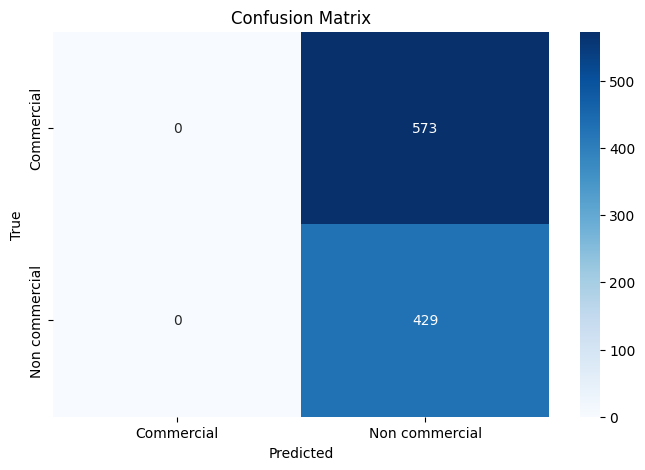

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_confusion_matrix(all_labels, all_preds)